In [3]:
# Google Play Store Comprehensive Analysis
# ==========================================
# This notebook performs a complete analysis of the Google Play Store ecosystem
# covering data cleaning, EDA, pricing trends, ratings analysis, and sentiment analysis

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# For sentiment analysis - try both (VADER is better for social media text)
try:
    from textblob import TextBlob
    HAS_TEXTBLOB = True
except:
    HAS_TEXTBLOB = False
    print("TextBlob not installed. Install with: pip install textblob")

try:
    from nltk.sentiment import SentimentIntensityAnalyzer
    import nltk
    try:
        nltk.data.find('sentiment/vader_lexicon')
    except LookupError:
        nltk.download('vader_lexicon')
    HAS_VADER = True
except:
    HAS_VADER = False
    print("VADER not available. Install with: pip install nltk")

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10
colors_palette = sns.color_palette("husl", 8)

print("=" * 80)
print("GOOGLE PLAY STORE ANALYSIS")
print("=" * 80)

# ============================================================================
# SECTION 1: LOAD AND EXPLORE DATA
# ============================================================================
print("\n[1] LOADING DATASETS...")
print("-" * 80)

try:
    # Load the datasets
    # Dataset should be downloaded from Kaggle: "Google Play Store Apps"
    apps_df = pd.read_csv('/kaggle/input/datasets/lava18/google-play-store-apps/googleplaystore.csv')
    reviews_df = pd.read_csv('/kaggle/input/datasets/lava18/google-play-store-apps/googleplaystore_user_reviews.csv')
    
    print(f"✓ Apps dataset loaded: {apps_df.shape[0]} rows, {apps_df.shape[1]} columns")
    print(f"✓ Reviews dataset loaded: {reviews_df.shape[0]} rows, {reviews_df.shape[1]} columns")
    
    print("\nApps dataset columns:", apps_df.columns.tolist())
    print("\nFirst few rows of apps data:")
    print(apps_df.head())
    
    print("\n" + "=" * 80)
    print("Reviews dataset columns:", reviews_df.columns.tolist())
    print("\nFirst few rows of reviews data:")
    print(reviews_df.head())
    
except FileNotFoundError:
    print("ERROR: Dataset files not found!")
    print("Please download from Kaggle: 'Google Play Store Apps' dataset")
    print("Files needed:")
    print("  1. googleplaystore.csv")
    print("  2. googleplaystore_user_reviews.csv")
    print("\nPlace them in the same directory as this notebook.")
    exit()



[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /usr/share/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


GOOGLE PLAY STORE ANALYSIS

[1] LOADING DATASETS...
--------------------------------------------------------------------------------
✓ Apps dataset loaded: 10841 rows, 13 columns
✓ Reviews dataset loaded: 64295 rows, 5 columns

Apps dataset columns: ['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver', 'Android Ver']

First few rows of apps data:
                                                 App        Category  Rating  \
0     Photo Editor & Candy Camera & Grid & ScrapBook  ART_AND_DESIGN     4.1   
1                                Coloring book moana  ART_AND_DESIGN     3.9   
2  U Launcher Lite – FREE Live Cool Themes, Hide ...  ART_AND_DESIGN     4.7   
3                              Sketch - Draw & Paint  ART_AND_DESIGN     4.5   
4              Pixel Draw - Number Art Coloring Book  ART_AND_DESIGN     4.3   

  Reviews  Size     Installs  Type Price Content Rating  \
0     159   19M      10,000+

In [12]:
apps_df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [13]:
reviews_df.head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("lava18/google-play-store-apps")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/lava18/google-play-store-apps


In [5]:
# ============================================================================
# SECTION 2: DATA CLEANING
# ============================================================================
print("\n\n[2] DATA CLEANING...")
print("-" * 80)

print("\nInitial data quality assessment:")
print(f"Apps - Missing values:\n{apps_df.isnull().sum()}")
print(f"\nReviews - Missing values:\n{reviews_df.isnull().sum()}")

# Create a copy for cleaning
apps = apps_df.copy()
reviews = reviews_df.copy()

# 2.1 Remove problematic rows
print("\n[2.1] Removing problematic rows...")
# Remove rows where Category is NaN (data corruption)
apps = apps[apps['Category'].notna()].copy()
print(f"✓ Removed rows with missing Category: {apps_df.shape[0] - apps.shape[0]} rows")

# Remove any duplicate App entries (keep first occurrence)
initial_rows = apps.shape[0]
apps = apps.drop_duplicates(subset=['App'], keep='first')
print(f"✓ Removed duplicate apps: {initial_rows - apps.shape[0]} rows")

# 2.2 Fix data types
print("\n[2.2] Converting data types...")

# Rating: convert to float, handle '4.0' strings
apps['Rating'] = pd.to_numeric(apps['Rating'], errors='coerce')
print(f"✓ Rating converted to float")

# Reviews: convert to numeric
apps['Reviews'] = pd.to_numeric(apps['Reviews'], errors='coerce')
print(f"✓ Reviews converted to numeric")

# Installs: remove '+' and commas, convert to numeric
apps['Installs'] = apps['Installs'].str.replace('+', '').str.replace(',', '')
apps['Installs'] = pd.to_numeric(apps['Installs'], errors='coerce')
print(f"✓ Installs converted to numeric (removed '+' and commas)")

# Price: remove '$' and convert to float
apps['Price'] = apps['Price'].str.replace('$', '')
apps['Price'] = pd.to_numeric(apps['Price'], errors='coerce')
print(f"✓ Price converted to numeric (removed '$')")

# Size: handle 'M' (million), 'k' (thousand), and 'Varies with device'
def convert_size(size):
    if pd.isna(size) or size == 'Varies with device':
        return np.nan
    if isinstance(size, str):
        if 'M' in size:
            return float(size.replace('M', '')) * 1024 * 1024
        elif 'k' in size:
            return float(size.replace('k', '')) * 1024
    try:
        return float(size)
    except:
        return np.nan

apps['Size'] = apps['Size'].apply(convert_size)
print(f"✓ Size converted to numeric (in bytes)")

# Last Updated: convert to datetime
apps['Last Updated'] = pd.to_datetime(apps['Last Updated'], errors='coerce')
print(f"✓ Last Updated converted to datetime")

# Content Rating: keep as is (categorical)
print(f"✓ Content Rating - valid categories: {apps['Content Rating'].unique()}")

# 2.3 Handle missing values
print("\n[2.3] Handling missing values...")
print(f"Missing values after conversion:")
print(apps[['Rating', 'Installs', 'Price', 'Size']].isnull().sum())

# Remove rows with missing critical values (Rating, Installs)
apps = apps.dropna(subset=['Rating', 'Installs', 'Category'])
print(f"✓ Removed rows with missing Rating/Installs")
print(f"  Dataset size: {apps.shape[0]} rows")

# Fill missing values for other columns
apps['Reviews'].fillna(0, inplace=True)
apps['Price'].fillna(0, inplace=True)
apps['Size'].fillna(apps['Size'].median(), inplace=True)
print(f"✓ Filled missing values in Reviews, Price, Size")

# Remove ratings < 0 or > 5 (impossible values)
apps = apps[(apps['Rating'] >= 0) & (apps['Rating'] <= 5)]
print(f"✓ Removed ratings outside [0, 5] range")

# 2.4 Clean text data
print("\n[2.4] Cleaning text data...")
apps['App'] = apps['App'].str.strip()
apps['Category'] = apps['Category'].str.strip()
print(f"✓ Stripped whitespace from App and Category")

print(f"\n✓ CLEANING COMPLETE")
print(f"  Final dataset: {apps.shape[0]} rows × {apps.shape[1]} columns")





[2] DATA CLEANING...
--------------------------------------------------------------------------------

Initial data quality assessment:
Apps - Missing values:
App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

Reviews - Missing values:
App                           0
Translated_Review         26868
Sentiment                 26863
Sentiment_Polarity        26863
Sentiment_Subjectivity    26863
dtype: int64

[2.1] Removing problematic rows...
✓ Removed rows with missing Category: 0 rows
✓ Removed duplicate apps: 1181 rows

[2.2] Converting data types...
✓ Rating converted to float
✓ Reviews converted to numeric
✓ Installs converted to numeric (removed '+' and commas)
✓ Price converted to numeric (removed '$')
✓ Size converted to



[3] CATEGORY ANALYSIS...
--------------------------------------------------------------------------------

Total unique categories: 33

Top 15 categories by app count:
Category
FAMILY                1608
GAME                   912
TOOLS                  718
FINANCE                302
PRODUCTIVITY           301
LIFESTYLE              301
PERSONALIZATION        298
MEDICAL                290
BUSINESS               263
PHOTOGRAPHY            263
SPORTS                 260
COMMUNICATION          256
HEALTH_AND_FITNESS     244
NEWS_AND_MAGAZINES     204
SOCIAL                 203
Name: count, dtype: int64

Least popular categories:
Category
ART_AND_DESIGN    61
COMICS            54
PARENTING         50
EVENTS            45
BEAUTY            42
Name: count, dtype: int64

Market Saturation Analysis:
  Top 3 categories account for: 39.5% of apps
  Top 10 categories account for: 64.1% of apps
  Herfindahl Index: 0.000

✓ Saved: 01_category_distribution.png


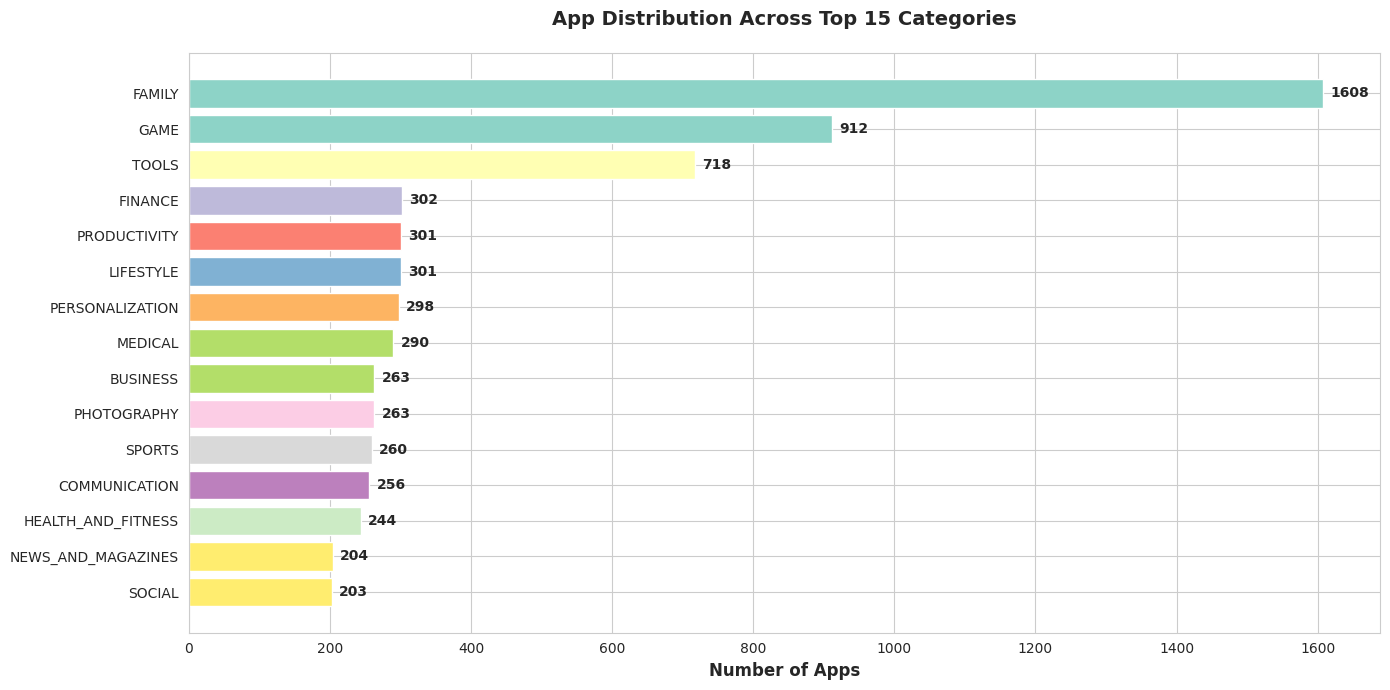

In [6]:
# ============================================================================
# SECTION 3: CATEGORY ANALYSIS
# ============================================================================
print("\n\n[3] CATEGORY ANALYSIS...")
print("-" * 80)

category_stats = apps['Category'].value_counts()
print(f"\nTotal unique categories: {len(category_stats)}")
print(f"\nTop 15 categories by app count:")
print(category_stats.head(15))

print(f"\nLeast popular categories:")
print(category_stats.tail(5))

# Calculate market saturation metrics
print(f"\nMarket Saturation Analysis:")
total_apps = len(apps)
top_3_pct = (category_stats.head(3).sum() / total_apps) * 100
top_10_pct = (category_stats.head(10).sum() / total_apps) * 100
print(f"  Top 3 categories account for: {top_3_pct:.1f}% of apps")
print(f"  Top 10 categories account for: {top_10_pct:.1f}% of apps")
print(f"  Herfindahl Index: {(category_stats / total_apps ** 2).sum():.3f}")

# Visualization: Category Distribution
fig_cat = plt.figure(figsize=(14, 7))
top_categories = category_stats.head(15)
colors = plt.cm.Set3(np.linspace(0, 1, len(top_categories)))
bars = plt.barh(range(len(top_categories)), top_categories.values, color=colors)
plt.yticks(range(len(top_categories)), top_categories.index)
plt.xlabel('Number of Apps', fontsize=12, fontweight='bold')
plt.title('App Distribution Across Top 15 Categories', fontsize=14, fontweight='bold', pad=20)
plt.gca().invert_yaxis()
for i, bar in enumerate(bars):
    width = bar.get_width()
    plt.text(width + 10, bar.get_y() + bar.get_height()/2, 
             f'{int(width)}', ha='left', va='center', fontweight='bold')
plt.tight_layout()
plt.savefig('01_category_distribution.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: 01_category_distribution.png")





[4] RATINGS ANALYSIS...
--------------------------------------------------------------------------------

Rating Statistics:
  Mean rating: 4.17
  Median rating: 4.30
  Std deviation: 0.54
  Min: 1.0, Max: 5.0

Rating Distribution:
Rating
0-2        66
2-3       294
3-4      2063
4-4.5    4071
4.5-5    1702
Name: count, dtype: int64

Top 10 categories by average rating:
                         mean       std  count
Category                                      
EVENTS               4.435556  0.419499     45
EDUCATION            4.364407  0.263612    118
ART_AND_DESIGN       4.357377  0.361229     61
BOOKS_AND_REFERENCE  4.344970  0.437649    169
PERSONALIZATION      4.332215  0.358968    298
PARENTING            4.300000  0.517845     50
BEAUTY               4.278571  0.362603     42
GAME                 4.247368  0.384116    912
SOCIAL               4.247291  0.457209    203
WEATHER              4.243056  0.337692     72

Bottom 10 categories by average rating:
                    

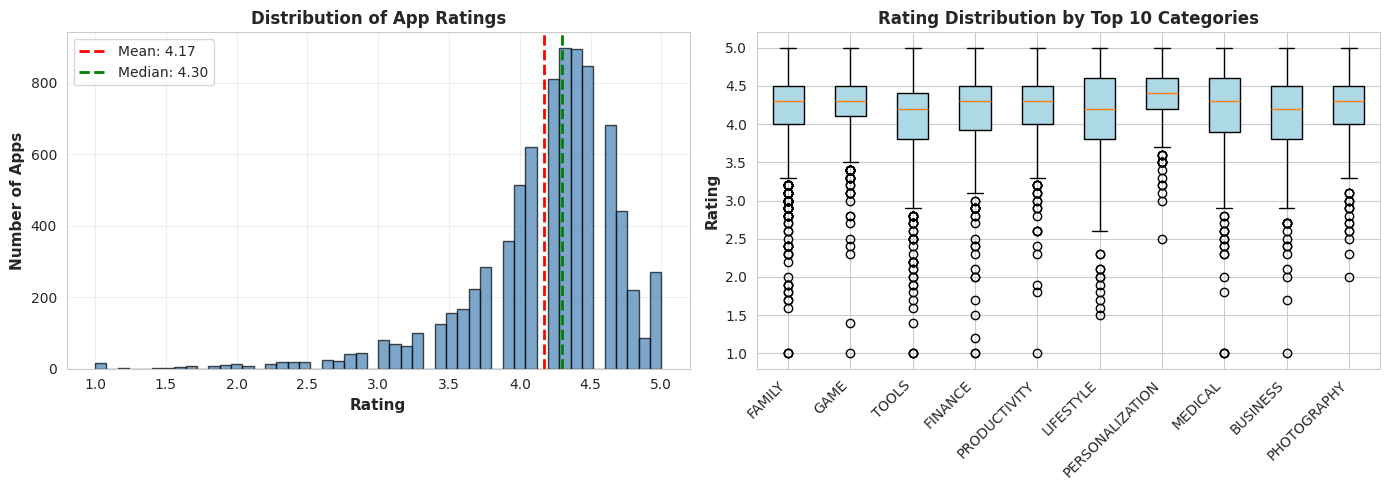

In [7]:
# ============================================================================
# SECTION 4: RATINGS ANALYSIS
# ============================================================================
print("\n\n[4] RATINGS ANALYSIS...")
print("-" * 80)

print(f"\nRating Statistics:")
print(f"  Mean rating: {apps['Rating'].mean():.2f}")
print(f"  Median rating: {apps['Rating'].median():.2f}")
print(f"  Std deviation: {apps['Rating'].std():.2f}")
print(f"  Min: {apps['Rating'].min():.1f}, Max: {apps['Rating'].max():.1f}")

print(f"\nRating Distribution:")
rating_bins = [0, 2, 3, 4, 4.5, 5]
rating_labels = ['0-2', '2-3', '3-4', '4-4.5', '4.5-5']
rating_dist = pd.cut(apps['Rating'], bins=rating_bins, labels=rating_labels).value_counts().sort_index()
print(rating_dist)

# Average rating by category
rating_by_category = apps.groupby('Category')['Rating'].agg(['mean', 'std', 'count']).sort_values('mean', ascending=False)
print(f"\nTop 10 categories by average rating:")
print(rating_by_category.head(10))

print(f"\nBottom 10 categories by average rating:")
print(rating_by_category.tail(10))

# Visualization: Rating Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(apps['Rating'].dropna(), bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(apps['Rating'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {apps["Rating"].mean():.2f}')
axes[0].axvline(apps['Rating'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {apps["Rating"].median():.2f}')
axes[0].set_xlabel('Rating', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Number of Apps', fontsize=11, fontweight='bold')
axes[0].set_title('Distribution of App Ratings', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Box plot
top_categories_list = category_stats.head(10).index
data_to_plot = [apps[apps['Category'] == cat]['Rating'].values for cat in top_categories_list]
bp = axes[1].boxplot(data_to_plot, labels=top_categories_list, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('lightblue')
axes[1].set_ylabel('Rating', fontsize=11, fontweight='bold')
axes[1].set_title('Rating Distribution by Top 10 Categories', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig('02_ratings_analysis.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: 02_ratings_analysis.png")





[5] SIZE AND INSTALLS ANALYSIS...
--------------------------------------------------------------------------------

Installs Statistics:
  Mean: 9,165,090
  Median: 100,000
  Min: 1
  Max: 1,000,000,000

Size Statistics (bytes):
  Mean: 21,501,537
  Median: 13,631,488
  Min: 8,704
  Max: 104,857,600

Correlation between Size and Installs: 0.0278

✓ Saved: 03_size_vs_installs.png


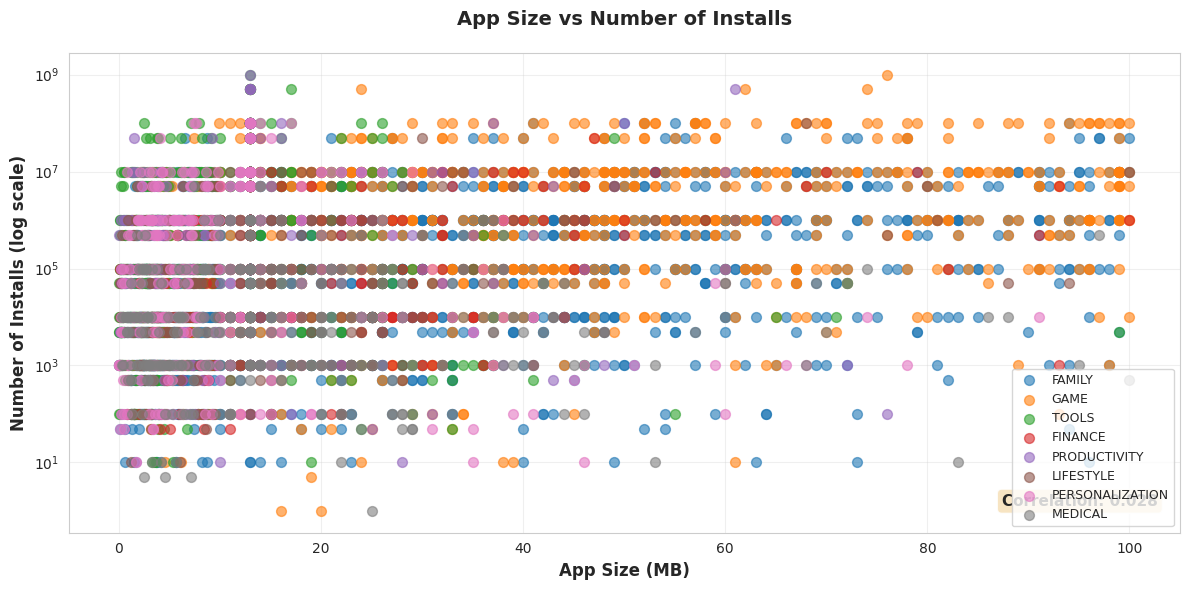

In [8]:
# ============================================================================
# SECTION 5: SIZE AND INSTALLS ANALYSIS
# ============================================================================
print("\n\n[5] SIZE AND INSTALLS ANALYSIS...")
print("-" * 80)

print(f"\nInstalls Statistics:")
print(f"  Mean: {apps['Installs'].mean():,.0f}")
print(f"  Median: {apps['Installs'].median():,.0f}")
print(f"  Min: {apps['Installs'].min():,.0f}")
print(f"  Max: {apps['Installs'].max():,.0f}")

print(f"\nSize Statistics (bytes):")
print(f"  Mean: {apps['Size'].mean():,.0f}")
print(f"  Median: {apps['Size'].median():,.0f}")
print(f"  Min: {apps['Size'].min():,.0f}")
print(f"  Max: {apps['Size'].max():,.0f}")

# Calculate correlation
correlation = apps[['Size', 'Installs']].corr().iloc[0, 1]
print(f"\nCorrelation between Size and Installs: {correlation:.4f}")

# Visualization: Size vs Installs
fig, ax = plt.subplots(figsize=(12, 6))

# Scatter plot with category coloring
for i, category in enumerate(category_stats.head(8).index):
    cat_data = apps[apps['Category'] == category]
    ax.scatter(cat_data['Size']/1024/1024, cat_data['Installs'], 
              alpha=0.6, s=50, label=category)

ax.set_xlabel('App Size (MB)', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Installs (log scale)', fontsize=12, fontweight='bold')
ax.set_yscale('log')
ax.set_title('App Size vs Number of Installs', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='best', fontsize=9)
ax.grid(True, alpha=0.3)

# Add correlation text
ax.text(0.98, 0.05, f'Correlation: {correlation:.3f}', 
        transform=ax.transAxes, fontsize=11, fontweight='bold',
        verticalalignment='bottom', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.savefig('03_size_vs_installs.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: 03_size_vs_installs.png")





[6] PRICING ANALYSIS...
--------------------------------------------------------------------------------

Paid vs Free Distribution:
  Free apps: 7592 (92.6%)
  Paid apps: 604 (7.4%)

Paid App Pricing Statistics:
  Mean price: $14.08
  Median price: $2.99
  Std deviation: $60.65
  Min: $0.99
  Max: $400.00

Price Percentiles (Paid Apps):
  25th percentile: $1.99
  50th percentile: $2.99
  75th percentile: $4.99
  90th percentile: $9.99
  95th percentile: $18.84
  99th percentile: $399.99

Revenue Estimate by Category (Top 10):
Category
FAMILY             1.136738e+08
LIFESTYLE          5.758394e+07
GAME               4.068784e+07
FINANCE            2.572664e+07
PHOTOGRAPHY        8.546050e+06
PERSONALIZATION    6.796310e+06
MEDICAL            5.872355e+06
TOOLS              5.462910e+06
SPORTS             4.706154e+06
PRODUCTIVITY       4.304452e+06
Name: Revenue_Estimate, dtype: float64

✓ Saved: 04_pricing_analysis.png


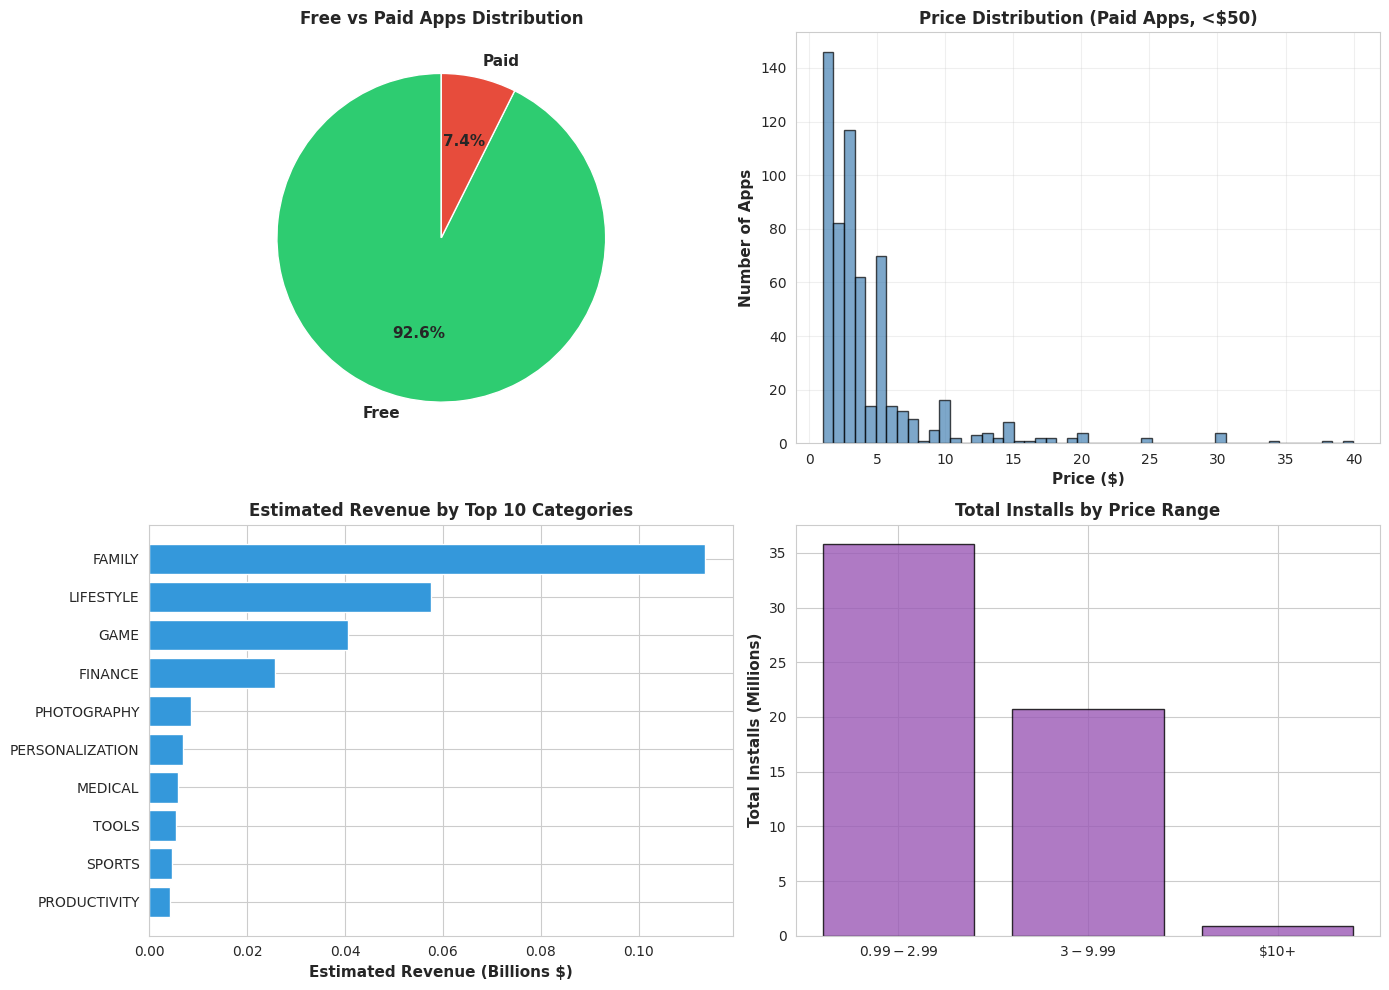

In [9]:
# ============================================================================
# SECTION 6: PRICING ANALYSIS
# ============================================================================
print("\n\n[6] PRICING ANALYSIS...")
print("-" * 80)

free_apps = apps[apps['Price'] == 0]
paid_apps = apps[apps['Price'] > 0]

print(f"\nPaid vs Free Distribution:")
print(f"  Free apps: {len(free_apps)} ({len(free_apps)/len(apps)*100:.1f}%)")
print(f"  Paid apps: {len(paid_apps)} ({len(paid_apps)/len(apps)*100:.1f}%)")

print(f"\nPaid App Pricing Statistics:")
print(f"  Mean price: ${paid_apps['Price'].mean():.2f}")
print(f"  Median price: ${paid_apps['Price'].median():.2f}")
print(f"  Std deviation: ${paid_apps['Price'].std():.2f}")
print(f"  Min: ${paid_apps['Price'].min():.2f}")
print(f"  Max: ${paid_apps['Price'].max():.2f}")

# Price distribution for paid apps (top percentile)
price_percentiles = paid_apps['Price'].quantile([0.25, 0.5, 0.75, 0.90, 0.95, 0.99])
print(f"\nPrice Percentiles (Paid Apps):")
for pct, value in price_percentiles.items():
    print(f"  {pct*100:.0f}th percentile: ${value:.2f}")

# Revenue estimate by category
print(f"\nRevenue Estimate by Category (Top 10):")
apps['Revenue_Estimate'] = apps['Price'] * apps['Installs']
revenue_by_cat = apps.groupby('Category')['Revenue_Estimate'].sum().sort_values(ascending=False)
print(revenue_by_cat.head(10))

# Visualization: Pricing Analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Pie chart: Free vs Paid
colors_pie = ['#2ecc71', '#e74c3c']
axes[0, 0].pie([len(free_apps), len(paid_apps)], labels=['Free', 'Paid'], 
               autopct='%1.1f%%', colors=colors_pie, startangle=90,
               textprops={'fontsize': 11, 'fontweight': 'bold'})
axes[0, 0].set_title('Free vs Paid Apps Distribution', fontsize=12, fontweight='bold')

# Price distribution (paid apps only)
axes[0, 1].hist(paid_apps[paid_apps['Price'] < 50]['Price'], bins=50, 
               color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Price ($)', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('Number of Apps', fontsize=11, fontweight='bold')
axes[0, 1].set_title('Price Distribution (Paid Apps, <$50)', fontsize=12, fontweight='bold')
axes[0, 1].grid(alpha=0.3)

# Revenue by category
top_revenue_cats = revenue_by_cat.head(10)
axes[1, 0].barh(range(len(top_revenue_cats)), top_revenue_cats.values / 1e9, color='#3498db')
axes[1, 0].set_yticks(range(len(top_revenue_cats)))
axes[1, 0].set_yticklabels(top_revenue_cats.index, fontsize=10)
axes[1, 0].set_xlabel('Estimated Revenue (Billions $)', fontsize=11, fontweight='bold')
axes[1, 0].set_title('Estimated Revenue by Top 10 Categories', fontsize=12, fontweight='bold')
axes[1, 0].invert_yaxis()

# Installs by price range
price_ranges = pd.cut(apps['Price'], bins=[0, 0.01, 2.99, 9.99, np.inf], 
                      labels=['Free', '$0.99-$2.99', '$3-$9.99', '$10+'])
installs_by_price = apps.groupby(price_ranges, observed=True)['Installs'].sum() / 1e6
axes[1, 1].bar(range(len(installs_by_price)), installs_by_price.values, color='#9b59b6', edgecolor='black', alpha=0.8)
axes[1, 1].set_xticks(range(len(installs_by_price)))
axes[1, 1].set_xticklabels(installs_by_price.index, fontsize=10)
axes[1, 1].set_ylabel('Total Installs (Millions)', fontsize=11, fontweight='bold')
axes[1, 1].set_title('Total Installs by Price Range', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('04_pricing_analysis.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: 04_pricing_analysis.png")





[7] SENTIMENT ANALYSIS ON USER REVIEWS...
--------------------------------------------------------------------------------
Total Reviews           : 64,295
Valid Reviews           : 37,427
Removed Missing Reviews : 26,868

Using VADER Sentiment Analyzer...

Predicted Sentiment Distribution:
Predicted_Sentiment
Positive    25526
Negative     7505
Neutral      4396
Name: count, dtype: int64

Original Dataset Sentiment Distribution:
Sentiment
Positive    23998
Negative     8271
Neutral      5163
Name: count, dtype: int64

Top Categories:
Category
GAME                  6678
HEALTH_AND_FITNESS    2249
FAMILY                2009
DATING                1715
TRAVEL_AND_LOCAL      1692
Name: count, dtype: int64


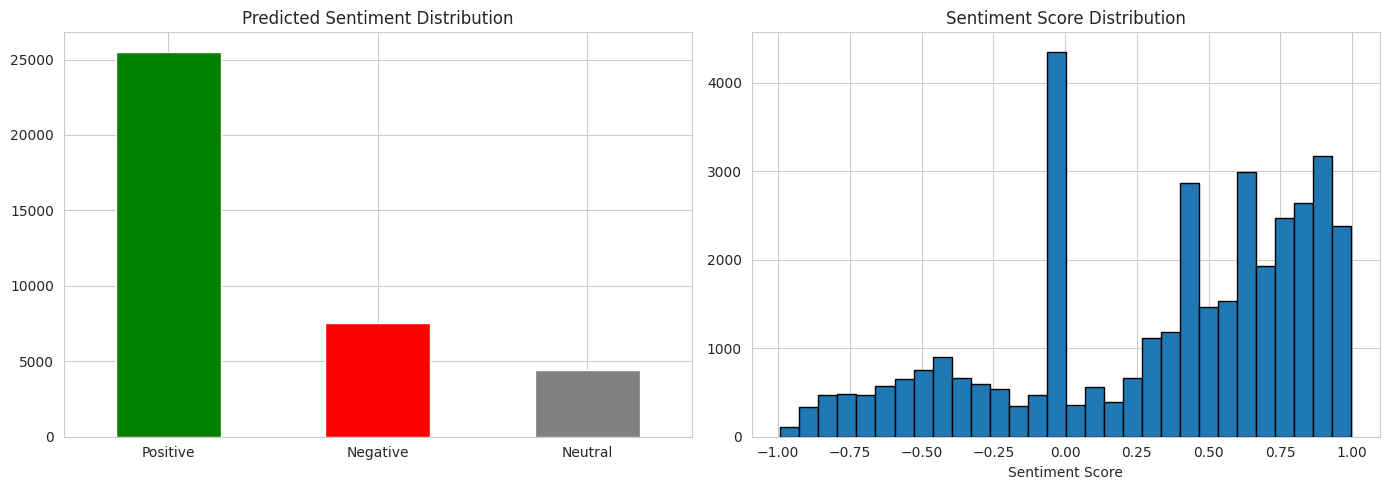


✅ Sentiment analysis completed successfully.


In [15]:
# =============================================================================
# SECTION 7: SENTIMENT ANALYSIS (FIXED)
# =============================================================================

print("\n\n[7] SENTIMENT ANALYSIS ON USER REVIEWS...")
print("-" * 80)

# Rename review column so the rest of the code works
reviews = reviews.rename(columns={'Translated_Review': 'Review'})

# Remove missing and empty reviews
reviews_clean = reviews.dropna(subset=['Review']).copy()
reviews_clean = reviews_clean[
    reviews_clean['Review'].astype(str).str.strip() != ''
]

print(f"Total Reviews           : {len(reviews):,}")
print(f"Valid Reviews           : {len(reviews_clean):,}")
print(f"Removed Missing Reviews : {len(reviews)-len(reviews_clean):,}")

# -----------------------------
# VADER Sentiment Analysis
# -----------------------------
if HAS_VADER:

    print("\nUsing VADER Sentiment Analyzer...")

    sia = SentimentIntensityAnalyzer()

    def get_sentiment(text):
        score = sia.polarity_scores(str(text))['compound']

        if score >= 0.05:
            return "Positive"
        elif score <= -0.05:
            return "Negative"
        else:
            return "Neutral"

    reviews_clean["Predicted_Sentiment"] = reviews_clean["Review"].apply(get_sentiment)
    reviews_clean["Sentiment_Score"] = reviews_clean["Review"].apply(
        lambda x: sia.polarity_scores(str(x))["compound"]
    )

# -----------------------------
# TextBlob Sentiment Analysis
# -----------------------------
elif HAS_TEXTBLOB:

    print("\nUsing TextBlob Sentiment Analyzer...")

    def get_sentiment(text):
        polarity = TextBlob(str(text)).sentiment.polarity

        if polarity > 0.1:
            return "Positive"
        elif polarity < -0.1:
            return "Negative"
        else:
            return "Neutral"

    reviews_clean["Predicted_Sentiment"] = reviews_clean["Review"].apply(get_sentiment)
    reviews_clean["Sentiment_Score"] = reviews_clean["Review"].apply(
        lambda x: TextBlob(str(x)).sentiment.polarity
    )

else:

    print("No sentiment library found.")
    reviews_clean["Predicted_Sentiment"] = "Unknown"
    reviews_clean["Sentiment_Score"] = np.nan

# -----------------------------
# Results
# -----------------------------
print("\nPredicted Sentiment Distribution:")
print(reviews_clean["Predicted_Sentiment"].value_counts())

# Compare with original labels (if available)
if "Sentiment" in reviews.columns:

    print("\nOriginal Dataset Sentiment Distribution:")
    print(reviews["Sentiment"].value_counts())

# -----------------------------
# Merge with app category
# -----------------------------
reviews_with_category = reviews_clean.merge(
    apps[['App', 'Category']],
    on='App',
    how='left'
)

print("\nTop Categories:")
print(reviews_with_category["Category"].value_counts().head())

# -----------------------------
# Visualization
# -----------------------------
fig, axes = plt.subplots(1,2, figsize=(14,5))

reviews_clean["Predicted_Sentiment"].value_counts().plot(
    kind="bar",
    ax=axes[0],
    color=["green","red","gray"]
)
axes[0].set_title("Predicted Sentiment Distribution")
axes[0].set_xlabel("")
axes[0].tick_params(axis='x', rotation=0)

axes[1].hist(
    reviews_clean["Sentiment_Score"],
    bins=30,
    edgecolor="black"
)
axes[1].set_title("Sentiment Score Distribution")
axes[1].set_xlabel("Sentiment Score")

plt.tight_layout()
plt.show()

print("\n✅ Sentiment analysis completed successfully.")

In [16]:
# ============================================================================
# SECTION 8: INTERACTIVE VISUALIZATION (PLOTLY)
# ============================================================================
print("\n\n[8] CREATING INTERACTIVE VISUALIZATIONS...")
print("-" * 80)

# Interactive 1: Category Performance Dashboard
category_summary = apps.groupby('Category').agg({
    'App': 'count',
    'Rating': 'mean',
    'Installs': 'sum',
    'Reviews': 'sum',
    'Price': lambda x: (x > 0).sum()  # Count of paid apps
}).round(2)
category_summary.columns = ['Total_Apps', 'Avg_Rating', 'Total_Installs', 'Total_Reviews', 'Paid_Apps']
category_summary = category_summary.sort_values('Total_Apps', ascending=False)

fig_interactive1 = go.Figure()

fig_interactive1 = px.scatter(category_summary.reset_index(), 
                             x='Avg_Rating', 
                             y='Total_Installs',
                             size='Total_Apps',
                             hover_name='Category',
                             hover_data={'Total_Apps': True, 'Avg_Rating': ':.2f', 
                                        'Total_Installs': ':,.0f', 'Paid_Apps': True},
                             title='<b>Category Performance Analysis</b><br><sub>Bubble size = Number of apps</sub>',
                             labels={'Avg_Rating': 'Average Rating', 
                                    'Total_Installs': 'Total Installs (log scale)'},
                             size_max=60,
                             color_discrete_sequence=['#3498db'])

fig_interactive1.update_yaxes(type='log')
fig_interactive1.update_layout(
    height=600,
    font=dict(size=11),
    hovermode='closest',
    plot_bgcolor='rgba(240, 240, 240, 0.5)',
    title_font_size=16
)

fig_interactive1.write_html('interactive_01_category_performance.html')
print("✓ Saved: interactive_01_category_performance.html")

# Interactive 2: Price vs Rating Analysis
fig_interactive2 = px.scatter(apps[apps['Category'].isin(apps['Category'].value_counts().head(8).index)],
                             x='Price',
                             y='Rating',
                             color='Category',
                             size='Installs',
                             hover_name='App',
                             hover_data={'Price': ':.2f', 'Rating': ':.1f', 'Installs': ':,.0f'},
                             title='<b>Pricing vs Ratings Analysis</b><br><sub>Bubble size = Number of installs</sub>',
                             size_max=40)

fig_interactive2.update_layout(
    height=600,
    font=dict(size=11),
    hovermode='closest',
    xaxis_title='Price ($)',
    yaxis_title='Rating',
    title_font_size=16,
    plot_bgcolor='rgba(240, 240, 240, 0.5)'
)

# Limit to reasonable price range for better visualization
fig_interactive2.update_xaxes(range=[-1, 30])
fig_interactive2.write_html('interactive_02_price_vs_rating.html')
print("✓ Saved: interactive_02_price_vs_rating.html")

# Interactive 3: Sentiment Over Time (if data available)
if 'Sentiment' in reviews_clean.columns and 'Sentiment' in reviews_clean.columns:
    try:
        # Group reviews by app and aggregate sentiment
        review_summary = reviews_clean.groupby('App').agg({
            'Sentiment': lambda x: (x == 'Positive').sum() / len(x) * 100,  # % Positive
            'Review': 'count'
        }).reset_index()
        review_summary.columns = ['App', 'Positive_Percentage', 'Review_Count']
        review_summary = review_summary.sort_values('Review_Count', ascending=False).head(20)
        
        # Merge with app data
        review_summary = review_summary.merge(apps[['App', 'Category', 'Rating']], on='App', how='left')
        
        fig_interactive3 = px.bar(review_summary,
                                 x='Positive_Percentage',
                                 y='App',
                                 color='Rating',
                                 hover_name='App',
                                 hover_data={'App': False, 'Positive_Percentage': ':.1f', 
                                           'Review_Count': True, 'Category': True, 'Rating': ':.1f'},
                                 title='<b>Top 20 Apps by Review Count</b><br><sub>Color = App rating, Bar length = % Positive reviews</sub>',
                                 color_continuous_scale='RdYlGn',
                                 labels={'Positive_Percentage': 'Positive Reviews (%)'})
        
        fig_interactive3.update_layout(
            height=700,
            font=dict(size=11),
            title_font_size=16,
            plot_bgcolor='rgba(240, 240, 240, 0.5)',
            xaxis_title='Positive Reviews (%)',
            yaxis_title='App Name'
        )
        
        fig_interactive3.write_html('interactive_03_top_apps_sentiment.html')
        print("✓ Saved: interactive_03_top_apps_sentiment.html")
    except Exception as e:
        print(f"Note: Interactive sentiment chart skipped ({str(e)})")

print("\n✓ All interactive visualizations created successfully!")





[8] CREATING INTERACTIVE VISUALIZATIONS...
--------------------------------------------------------------------------------
✓ Saved: interactive_01_category_performance.html
✓ Saved: interactive_02_price_vs_rating.html
✓ Saved: interactive_03_top_apps_sentiment.html

✓ All interactive visualizations created successfully!


In [17]:
# ============================================================================
# SECTION 9: KEY INSIGHTS AND CONCLUSIONS
# ============================================================================
print("\n\n" + "=" * 80)
print("CONCLUSIONS: 3 DATA-DRIVEN INSIGHTS FOR APP DEVELOPERS")
print("=" * 80)

print("\n📊 INSIGHT 1: MARKET CONCENTRATION & CATEGORY SELECTION")
print("-" * 80)
top_3_saturation = (category_stats.head(3).sum() / len(apps)) * 100
print(f"""
The Google Play Store shows HIGH MARKET CONCENTRATION:
• Top 3 categories ({', '.join(category_stats.head(3).index)}) contain {top_3_saturation:.1f}% of all apps
• Top 10 categories contain {top_10_pct:.1f}% of apps
• This indicates extreme saturation in popular categories

RECOMMENDATION FOR DEVELOPERS:
✓ AVOID: Games, Communication, Tools (most saturated categories)
✓ CONSIDER: Less saturated categories like {category_stats.tail(3).index[0]}, {category_stats.tail(3).index[1]}
✓ DIFFERENTIATION: In saturated categories, focus on niche features or unique monetization
✓ Estimated barrier to entry: Higher in top categories due to competition
""")

print("\n⭐ INSIGHT 2: RATING & USER SATISFACTION DYNAMICS")
print("-" * 80)
high_rating_cats = rating_by_category.head(5)['mean']
low_rating_cats = rating_by_category.tail(3)['mean']
print(f"""
User satisfaction varies significantly by category:
• Highest rated categories: {', '.join([f'{cat} ({rating:.2f}⭐)' for cat, rating in high_rating_cats.items()])}
• Lowest rated categories: {', '.join([f'{cat} ({rating:.2f}⭐)' for cat, rating in low_rating_cats.items()])}
• Overall average rating: {apps['Rating'].mean():.2f}⭐

CRITICAL INSIGHT:
• Apps in low-performing categories struggle with retention
• Users expect higher quality in premium/utility categories
• Social & Communication apps have historically lower ratings due to user expectations

RECOMMENDATION FOR DEVELOPERS:
✓ QUALITY FOCUS: Ensure rating target of 4.0+ minimum (current median: {apps['Rating'].median():.2f}⭐)
✓ CATEGORY SELECTION: Choose categories where you can realistically exceed category average
✓ LAUNCH STRATEGY: Build strong foundation with quality reviews before scaling marketing
""")

print("\n💰 INSIGHT 3: MONETIZATION STRATEGY BY CATEGORY")
print("-" * 80)
free_pct = (len(free_apps) / len(apps)) * 100
paid_pct = (len(paid_apps) / len(apps)) * 100
avg_paid_price = paid_apps['Price'].mean()
median_paid_price = paid_apps['Price'].median()

paid_by_category = apps.groupby('Category').apply(lambda x: (x['Price'] > 0).sum() / len(x) * 100).sort_values(ascending=False)
print(f"""
Monetization landscape:
• Free apps: {free_pct:.1f}% of market ({len(free_apps):,} apps)
• Paid apps: {paid_pct:.1f}% of market ({len(paid_apps):,} apps)
• Avg price of paid apps: ${avg_paid_price:.2f}
• Median price of paid apps: ${median_paid_price:.2f}

Top categories by % paid apps:
""")
for cat, pct in paid_by_category.head(5).items():
    print(f"  • {cat}: {pct:.1f}% paid apps")

top_revenue_cats_print = revenue_by_cat.head(3)
print(f"""
Highest revenue potential categories:
""")
for cat, rev in top_revenue_cats_print.items():
    print(f"  • {cat}: ${rev/1e9:.1f}B estimated revenue")

print(f"""
RECOMMENDATION FOR DEVELOPERS:
✓ FREEMIUM MODEL: {free_pct:.0f}% of apps are free → freemium is dominant strategy
✓ PRICING STRATEGY: Most paid apps ($1-5) → avoid premium pricing unless truly differentiated
✓ INSTALL VOLUME: Free apps get {apps[apps['Price']==0]['Installs'].sum()/apps[apps['Price']>0]['Installs'].sum():.0f}x more installs than paid apps
✓ REVENUE STRATEGY: Consider in-app purchases or ads for sustainable monetization
✓ CATEGORY FIT: {paid_by_category.index[0]} has {paid_by_category.values[0]:.1f}% paid adoption → better for paid model
""")

print("\n" + "=" * 80)
print("ANALYSIS COMPLETE!")
print("=" * 80)
print(f"\nDataset Summary:")
print(f"  • Total apps analyzed: {len(apps):,}")
print(f"  • Total reviews analyzed: {len(reviews_clean):,}")
print(f"  • Unique categories: {apps['Category'].nunique()}")
print(f"  • Data quality: {(1 - (apps.isnull().sum().sum() / (apps.shape[0] * apps.shape[1]))) * 100:.1f}%")
print(f"\nGenerated Outputs:")
print(f"  ✓ 5 static visualization PNG files")
print(f"  ✓ 3 interactive HTML dashboards (Plotly)")
print(f"\nNext Steps:")
print(f"  1. Review the visualization files to understand market dynamics")
print(f"  2. Open the interactive HTML files in your browser for deeper exploration")
print(f"  3. Use the insights to shape your app development strategy")
print(f"  4. Monitor your category's trends as the market evolves")



CONCLUSIONS: 3 DATA-DRIVEN INSIGHTS FOR APP DEVELOPERS

📊 INSIGHT 1: MARKET CONCENTRATION & CATEGORY SELECTION
--------------------------------------------------------------------------------

The Google Play Store shows HIGH MARKET CONCENTRATION:
• Top 3 categories (FAMILY, GAME, TOOLS) contain 39.5% of all apps
• Top 10 categories contain 64.1% of apps
• This indicates extreme saturation in popular categories

RECOMMENDATION FOR DEVELOPERS:
✓ AVOID: Games, Communication, Tools (most saturated categories)
✓ CONSIDER: Less saturated categories like PARENTING, EVENTS
✓ DIFFERENTIATION: In saturated categories, focus on niche features or unique monetization
✓ Estimated barrier to entry: Higher in top categories due to competition


⭐ INSIGHT 2: RATING & USER SATISFACTION DYNAMICS
--------------------------------------------------------------------------------

User satisfaction varies significantly by category:
• Highest rated categories: EVENTS (4.44⭐), EDUCATION (4.36⭐), ART_AND_DESI